## 1. What this notebook computes

The spin connection $\omega$ carries one coordinate index and two frame indices.
The Revision record builds the spinor connection from the components with BOTH
frame indices down,

$$\Omega_\mu = \tfrac12 \sum_{a,b} \omega_{\mu ab} S^{ab}, \qquad
\omega_{\mu ab} = \eta_{aa}\,\omega_\mu{}^a{}_b ,$$

and it records (Revision/SPEC.md, section 3) that the author's Mathematica
notebook contracts the **mixed** components $\omega_\mu{}^a{}_b$ (first frame index
up) with $S^{ab}$ instead; that contraction lacks one factor of the frame metric
$\eta$ and is not used. This notebook shows, exactly, what the missing factor does.
We call the notebook's contraction

$$\Omega^{nb}_\mu = \tfrac12 \sum_{a,b} \omega_\mu{}^a{}_b S^{ab}$$

("nb" for notebook). The notebook

- proves that $\Omega^{nb}_\mu$ keeps the 6 space-space parts of $\Omega_\mu$,
  reverses the sign of the 6 time-time parts and DELETES the 16 boost parts;
- shows that the two contractions agree in a space whose metric is positive (the
  flat plane in polar coordinates), and that in a flat plane with one time (the
  **Milne wedge**) the notebook's contraction deletes the whole connection;
- computes, for the author's metric, what the notebook's contraction would give:
  $\gamma^\mu\Omega^{nb}_\mu = \frac{3H}{2}\gamma^{(x8)} +
  \frac{3a_4'}{2}\gamma^{(x4)}$ instead of the correct $3H\gamma^{(x8)}$;
- counts where it breaks the covariant constancy $D_\mu\gamma^\nu = 0$ of the
  gammas (15 of the 64 pairs $(\mu, \nu)$);
- shows the physical reason why only the value $3H$ is right: it makes the
  hidden-direction operator antisymmetric for the volume weight $\cos z$, as the
  Revision record proves;
- draws six teaching plots.

Every correct result is compared with the Revision record. The results about
$\Omega^{nb}$ are computed by this notebook itself; they describe what the
notebook's contraction WOULD give, and the book uses them nowhere else.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 06c (One missing metric factor: the mixed contraction of the spin connection) is
the file `Revision/textbook/notebooks/06c_mixed_contraction.ipynb` of the repository
Dirac_claude. The Revision record builds the spinor connection from the spin connection
with its first frame index lowered by the frame metric eta, and records that the author's
Mathematica notebook contracts the mixed components instead, which lacks this metric
factor. This notebook proves exactly, with sympy, what the missing factor does: it
deletes the 16 boost components of every spin connection and reverses the sign of the 6
time-time components; it changes nothing in a space with a positive metric (the polar
plane) and deletes the whole connection of a flat plane with one time (the Milne wedge);
in the author's metric it would give gamma^mu Omega_mu = (3 H/2) gamma^(x8) + (3 a4'/2)
gamma^(x4) instead of 3 H gamma^(x8), break the covariant constancy of the gammas in 15
of the 64 pairs, and spoil the antisymmetry of the hidden-direction operator that the
Revision record proves for the correct value 3 H. It checks the correct results against
the Revision records and draws six teaching plots. It needs a computer with Windows 11,
macOS or Linux, an internet connection for the installation, the program Git, and Python
3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 06c_mixed_contraction.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 45 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 06c_mixed_contraction.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
06c_mixed_contraction.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/06c.captions.json`
- `Revision/textbook/figures/06c_1_pair_kinds.png`
- `Revision/textbook/figures/06c_2_milne_frame_and_spin_boost.png`
- `Revision/textbook/figures/06c_3_per_direction_comparison.png`
- `Revision/textbook/figures/06c_4_contraction_heat_maps.png`
- `Revision/textbook/figures/06c_5_constancy_violation.png`
- `Revision/textbook/figures/06c_6_hermiticity_defect.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS all six figure files exist
    ALL 27 CHECKS PASSED (notebook 06c)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/06c_mixed_contraction.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for Revision/algebra/gammas.json, Revision/SPEC.md or a report: the
  notebook reads Revision records from the repository; open it inside the folder
  Revision/textbook/notebooks of a complete copy of the repository Dirac_claude (a single
  downloaded notebook file is not enough).
- a cell runs for several minutes: the exact algebra of sympy is slow on old computers;
  the whole notebook needs less than a minute on a 2024 laptop, and up to about two
  minutes while other programs use the processor. Wait, or close the other programs.
- "Jupyter command `jupyter-nbconvert` not found" or "Jupyter command `jupyter-lab` not
  found" after typing `python -m jupyter`: the program jupyter starts its parts nbconvert
  and lab as separate programs, which it looks for in the folders of the search path
  PATH, and the folder that holds them is not on it. Start the two parts as Python
  modules instead, with the environment active (Step 4) and in the folder
  Revision/textbook/notebooks (Step 5): the first command below opens the notebook in
  JupyterLab, the second runs it headless

      python -m jupyterlab 06c_mixed_contraction.ipynb
      python -m nbconvert --to notebook --execute --inplace 06c_mixed_contraction.ipynb

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 06c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 06c (One missing metric factor: the mixed contraction of the spin connection)
# is the file Revision/textbook/notebooks/06c_mixed_contraction.ipynb of the repository
# Dirac_claude. The Revision record builds the spinor connection from the spin connection
# with its first frame index lowered by the frame metric eta, and records that the
# author's Mathematica notebook contracts the mixed components instead, which lacks this
# metric factor. This notebook proves exactly, with sympy, what the missing factor does:
# it deletes the 16 boost components of every spin connection and reverses the sign of
# the 6 time-time components; it changes nothing in a space with a positive metric (the
# polar plane) and deletes the whole connection of a flat plane with one time (the Milne
# wedge); in the author's metric it would give gamma^mu Omega_mu = (3 H/2) gamma^(x8) +
# (3 a4'/2) gamma^(x4) instead of 3 H gamma^(x8), break the covariant constancy of the
# gammas in 15 of the 64 pairs, and spoil the antisymmetry of the hidden-direction
# operator that the Revision record proves for the correct value 3 H. It checks the
# correct results against the Revision records and draws six teaching plots. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the
# other packages run Jupyter, the program that shows and runs notebooks. It does not need
# Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 06c_mixed_contraction.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 45
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 06c_mixed_contraction.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 06c_mixed_contraction.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/06c.captions.json
# - Revision/textbook/figures/06c_1_pair_kinds.png
# - Revision/textbook/figures/06c_2_milne_frame_and_spin_boost.png
# - Revision/textbook/figures/06c_3_per_direction_comparison.png
# - Revision/textbook/figures/06c_4_contraction_heat_maps.png
# - Revision/textbook/figures/06c_5_constancy_violation.png
# - Revision/textbook/figures/06c_6_hermiticity_defect.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS all six figure files exist
#     ALL 27 CHECKS PASSED (notebook 06c)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/06c_mixed_contraction.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for Revision/algebra/gammas.json, Revision/SPEC.md or a report:
#   the notebook reads Revision records from the repository; open it inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository Dirac_claude (a
#   single downloaded notebook file is not enough).
# - a cell runs for several minutes: the exact algebra of sympy is slow on old computers;
#   the whole notebook needs less than a minute on a 2024 laptop, and up to about two
#   minutes while other programs use the processor. Wait, or close the other programs.
# - "Jupyter command jupyter-nbconvert not found" or "Jupyter command jupyter-lab not
#   found" after typing python -m jupyter: the program jupyter starts its parts nbconvert
#   and lab as separate programs, which it looks for in the folders of the search path
#   PATH, and the folder that holds them is not on it. Start the two parts as Python
#   modules instead, with the environment active (Step 4) and in the folder
#   Revision/textbook/notebooks (Step 5): the first command below opens the notebook in
#   JupyterLab, the second runs it headless
#     python -m jupyterlab 06c_mixed_contraction.ipynb
#     python -m nbconvert --to notebook --execute --inplace 06c_mixed_contraction.ipynb
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "06c"  # this notebook: chapter 06, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 06c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x1, \dots, x8$ with the author's names: $x1, x2, x3$ 3-space;
  $x4$ the time; $x5, x6, x7$ the three **extra times**; $x8$ the **hidden
  direction**; $z = 6Hx_8$. In Python lists they have the positions 0 to 7.
- **Frame metric** $\eta = \mathrm{diag}(+1,+1,+1,-1,-1,-1,-1,+1)$ in the order
  $x1, \dots, x8$: $\eta_{aa} = +1$ for a **space-like** frame direction, $-1$ for a
  **time-like** one. Because $\eta$ is diagonal with entries $\pm1$,
  $\eta_{aa}\eta_{aa} = 1$.
- **Upper and lower frame index.** The spin connection comes out of its formula
  with the first frame index UP, $\omega_\mu{}^a{}_b$: these are the **mixed
  components**. **Lowering** the index means multiplying by $\eta$:
  $\omega_{\mu ab} = \eta_{aa}\,\omega_\mu{}^a{}_b$ (no sum). The lowered
  components are **antisymmetric**, $\omega_{\mu ba} = -\omega_{\mu ab}$.
- $S^{ab} = \frac14[\gamma^a, \gamma^b]$: the 28 generators (one for each pair
  $a < b$); $S^{ba} = -S^{ab}$ and $S^{aa} = 0$.
- **Kinds of pairs** $\{a, b\}$ of two different frame directions:
  **space-space** (both space-like), **time-time** (both time-like) and
  **boost pair** (one space-like and one time-like). A boost pair generates a
  boost, the other two kinds generate rotations.
- **Spinor connection** $\Omega_\mu$ (correct) and $\Omega^{nb}_\mu$ (the
  notebook's contraction). $\Omega^{ss}_\mu$, $\Omega^{tt}_\mu$, $\Omega^{st}_\mu$:
  the parts of $\Omega_\mu$ that come from the space-space, time-time and boost
  pairs.
- **Defining property** of a spinor connection: $[\Omega_\mu, \gamma^a] =
  -\sum_b \omega_\mu{}^a{}_b\gamma^b$; **covariant constancy** of the curved gammas
  $\gamma^\mu = \sum_a e_a{}^\mu\gamma^a$: $D_\mu\gamma^\nu = \partial_\mu\gamma^\nu
  + \sum_\lambda\Gamma^\nu{}_{\mu\lambda}\gamma^\lambda + [\Omega_\mu, \gamma^\nu]
  = 0$.
- **Milne wedge**: the part $t > |y|$ of the flat plane with one time $t$ and one
  space direction $y$, $ds^2 = -dt^2 + dy^2$, described by $\tau =
  \sqrt{t^2 - y^2}$ and $\theta$ with $t = \tau\cosh\theta$, $y = \tau\sinh\theta$;
  its metric is $ds^2 = -d\tau^2 + \tau^2 d\theta^2$.
- **Spinor boost**: a matrix $U$ that turns spinors when the frame is boosted.
- **Antisymmetric for a weight**: an operator $A$ acting on functions of $x_8$ is
  antisymmetric for the weight $w(x_8)$ when $\int w\,p\,(Aq)\,dx_8 = -\int
  w\,(Ap)\,q\,dx_8$ for all functions $p, q$, up to boundary terms.
- **Exact** check: sympy proves that an expression is zero for ALL values of its
  symbols. **Heat map**: a picture of a matrix, one coloured square per entry.

## 4. The physical and mathematical situation

**The derivation, line by line.** Start from the notebook's contraction,

$$\Omega^{nb}_\mu = \tfrac12 \sum_{a,b} \omega_\mu{}^a{}_b S^{ab} .$$

Lowering is multiplication by $\eta_{aa}$, and $\eta_{aa}\eta_{aa} = 1$, so
$\omega_\mu{}^a{}_b = \eta_{aa}\,\omega_{\mu ab}$ (multiply
$\omega_{\mu ab} = \eta_{aa}\omega_\mu{}^a{}_b$ by $\eta_{aa}$):

$$\Omega^{nb}_\mu = \tfrac12 \sum_{a,b} \eta_{aa}\,\omega_{\mu ab} S^{ab} .$$

The terms with $a = b$ vanish ($S^{aa} = 0$). Every other term belongs to exactly
one unordered pair $\{a, b\}$ with $a < b$, which contributes two terms:

$$\eta_{aa}\,\omega_{\mu ab}S^{ab} + \eta_{bb}\,\omega_{\mu ba}S^{ba} =
(\eta_{aa} + \eta_{bb})\,\omega_{\mu ab}S^{ab} ,$$

because $\omega_{\mu ba}S^{ba} = (-\omega_{\mu ab})(-S^{ab}) = \omega_{\mu ab}
S^{ab}$ (both factors change sign). Hence

$$\Omega^{nb}_\mu = \sum_{a<b} \tfrac12(\eta_{aa} + \eta_{bb})\,
\omega_{\mu ab}S^{ab} ,$$

while the same steps without $\eta$ give the correct $\Omega_\mu = \sum_{a<b}
\omega_{\mu ab}S^{ab}$. The factor $\frac12(\eta_{aa} + \eta_{bb})$ is $+1$ for a
space-space pair, $-1$ for a time-time pair and $0$ for a boost pair. So

$$\Omega^{nb}_\mu = \Omega^{ss}_\mu - \Omega^{tt}_\mu, \qquad
\Omega_\mu = \Omega^{ss}_\mu + \Omega^{tt}_\mu + \Omega^{st}_\mu .$$

In a space whose metric is positive (every $\eta_{aa} = +1$) the factor is always
$+1$ and the two contractions are the same: the mistake cannot be seen in the usual
textbook examples. In signature (4,4) it deletes 16 of the 28 parts.

**Status.** The identity above is PROVED here (exact algebra). The values of
$\Omega^{nb}$ below are COMPUTED exactly by this notebook for the author's metric
and describe the contraction that the Revision record does NOT use. The correct
values ($\Omega_\mu$, $\gamma^\mu\Omega_\mu = 3H\gamma^{(x8)}$, $D_\mu\gamma^\nu = 0$,
the antisymmetry of the hidden-direction operator) reproduce the Revision record.

## 5. The tools: sympy, the author's gammas and the record

The next cell imports numpy (numbers for the plots) and sympy (exact algebra),
reads the author's eight gamma matrices from `Revision/algebra/gammas.json`, checks
the 64 Clifford relations and that they are eight real 16 x 16 matrices, builds
the matrices $S^{ab}$, and defines the exact zero test `is_zero` (first a fast route
through exponential functions, then sympy's `simplify`; it never calls a nonzero
expression zero), `matrix_is_zero` and `record_passed` (does a Revision report
record a check as passed?). It reads the formulas of
`Revision/theory/field-theory.json` and checks that `Revision/SPEC.md` (section 3)
contains the statement about the notebook's contraction.

The first lines of the next cell change one setting of Jupyter: printed text is
sent to the screen when a cell has finished (or just before a figure is shown),
not every 0.2 seconds. This changes no result; it makes the printed text arrive in
the same pieces in every run, which the book's checking tool needs.

In [2]:
import sys  # the Python system module (here: the stream of printed text)

# Jupyter sends printed text to the screen in pieces, about every 0.2 seconds.  The
# book's checking tool reads each PASS line together with its "reproduces" line, so
# the pieces must be the same in every run: send the printed text of a cell in one
# piece when the cell ends (or just before a figure), at the latest after 600 s.
if hasattr(sys.stdout, "flush_interval"):  # true inside Jupyter only
    sys.stdout.flush_interval = 600.0
import numpy as np  # decimal numbers (only for the plots)
import sympy as sp  # exact algebra and calculus with symbols

fixture = json.loads(repository_file("Revision/algebra/gammas.json").read_text(
    encoding="utf-8"))
NAMES = fixture["coordinates"]  # ["x1", ..., "x8"]
ETA = fixture["eta"]  # +1 space-like, -1 time-like
gamma = [sp.Matrix(rows) for rows in fixture["gamma"]]  # gamma[a] = gamma^(x(a+1))
I16, Z16 = sp.eye(16), sp.zeros(16, 16)  # identity and zero matrix
check(all(gamma[a] * gamma[b] + gamma[b] * gamma[a]
          == (2 * ETA[a] if a == b else 0) * I16
          for a in range(8) for b in range(8)),
      "the 64 Clifford relations of the author's gammas",
      record="Revision/theory/reports/python-field-theory.json, "
             "check clifford_relations")
check(len(gamma) == 8 and all(M.shape == (16, 16) for M in gamma)
      and all(entry.is_real for M in gamma for entry in M),
      "the eight gammas are 16 x 16 matrices with real entries",
      record="Revision/theory/reports/python-field-theory.json, check gammas_real")
S = [[(gamma[a] * gamma[b] - gamma[b] * gamma[a]) / 4 for b in range(8)]
     for a in range(8)]  # S[a][b] = S^ab


def is_zero(expr):
    """True when expr is exactly zero for all values of its symbols."""
    expr = sp.sympify(expr)
    if expr == 0:
        return True
    if sp.cancel(sp.expand(expr.rewrite(sp.exp))) == 0:  # the fast route
        return True
    return sp.simplify(expr) == 0  # the slower general route


def matrix_is_zero(matrix):
    """True when every entry of the matrix is exactly zero."""
    return all(is_zero(entry) for entry in matrix)


def record_passed(path, name):
    """True when the Revision report at path records the check name as passed."""
    data = json.loads(repository_file(path).read_text(encoding="utf-8"))
    for entry in data["checks"]:
        if entry["name"] == name:
            return entry["verdict"].upper() == "PASS"  # "PASS" or "pass"
    raise KeyError(f"{path} has no check {name}")


THEORY_FILE = "Revision/theory/field-theory.json"
FORMULAS = {item["key"]: item["wl"] for item in json.loads(
    repository_file(THEORY_FILE).read_text(encoding="utf-8"))["formulas"]}
REPORT_PY = "Revision/theory/reports/python-field-theory.json"
REPORT_WL = "Revision/theory/reports/wolfram-field-theory.json"
# " ".join(text.split()) replaces every run of blanks and line breaks by one blank,
# so a sentence that the file breaks across two lines is found as one line.
spec_text = " ".join(repository_file("Revision/SPEC.md").read_text(
    encoding="utf-8").split())
statement = "contraction of the mixed omega_mu^a_b, which lacks a metric factor"
check(statement in spec_text,
      "Revision/SPEC.md section 3 records the missing metric factor")

PASS the 64 Clifford relations of the author's gammas
     reproduces Revision/theory/reports/python-field-theory.json, check
    clifford_relations
PASS the eight gammas are 16 x 16 matrices with real entries
     reproduces Revision/theory/reports/python-field-theory.json, check gammas_real
PASS Revision/SPEC.md section 3 records the missing metric factor


The next cell defines the general formulas as Python functions. They work in any
number of dimensions, for any vielbein matrix `e` (row = frame index, column =
coordinate; its inverse `E = e.inv()` has `E[nu, b]` $= e_b{}^\nu$).

- `christoffel(g, coords)`: $\Gamma^l{}_{mn}$, computed once for each pair
  $m \le n$.
- `mixed_spin_connection(e, Gam, coords)`: the MIXED components
  $\omega_\mu{}^a{}_b = \sum_\nu e^a{}_\nu(\partial_\mu e_b{}^\nu +
  \sum_\lambda\Gamma^\nu{}_{\mu\lambda}e_b{}^\lambda)$, exactly as the formula
  gives them.
- `lower_first_index(mixed, eta)`: $\omega_{\mu ab} = \eta_{aa}\,
  \omega_\mu{}^a{}_b$.
- `contract(coefficients, gens)`: $\frac12\sum_{a,b}c_{\mu ab}\,S^{ab}$ for every
  $\mu$, summed over ALL ordered pairs $(a, b)$. (Notebook 06a summed over $a < b$
  only, which is allowed for the antisymmetric lowered components; the mixed
  components are not antisymmetric, so here the full sum is needed.)
- `curved_gammas(e, gammas)`: $\gamma^\mu = \sum_a e_a{}^\mu\gamma^a$.
- `generators(gammas)`: the matrices $S^{ab} = \frac14[\gamma^a, \gamma^b]$.

In [3]:
def christoffel(g, coords):
    """Gam[l][m][n] = (1/2) sum_r g^lr (d_m g_rn + d_n g_rm - d_r g_mn)."""
    n = len(coords)
    g_inv = g.inv()  # the inverse metric
    Gam = [[[sp.Integer(0)] * n for _ in range(n)] for _ in range(n)]
    for l in range(n):
        for m in range(n):
            for k in range(m, n):  # Gamma^l_mk = Gamma^l_km: compute it once
                value = sum(g_inv[l, r] * (sp.diff(g[r, k], coords[m])
                                           + sp.diff(g[r, m], coords[k])
                                           - sp.diff(g[m, k], coords[r]))
                            for r in range(n) if g_inv[l, r] != 0) / 2
                Gam[l][m][k] = Gam[l][k][m] = sp.simplify(value)
    return Gam


def mixed_spin_connection(e, Gam, coords):
    """mixed[mu][a][b] = omega_mu^a_b (first frame index up)."""
    n = len(coords)
    E = e.inv()  # E[nu, b] = e_b^nu, the inverse vielbein
    mixed = [[[sp.Integer(0)] * n for _ in range(n)] for _ in range(n)]
    for mu in range(n):
        for a in range(n):
            for b in range(n):
                value = 0
                for nu in range(n):
                    if e[a, nu] == 0:
                        continue  # this term is zero
                    value += e[a, nu] * (sp.diff(E[nu, b], coords[mu]) + sum(
                        Gam[nu][mu][lam] * E[lam, b] for lam in range(n)))
                mixed[mu][a][b] = sp.simplify(value)
    return mixed


def lower_first_index(mixed, eta):
    """omega[mu][a][b] = eta_aa omega_mu^a_b (eta is diagonal)."""
    n = len(mixed)
    return [[[eta[a] * mixed[mu][a][b] for b in range(n)] for a in range(n)]
            for mu in range(n)]


def contract(coefficients, gens):
    """(1/2) sum over ALL ordered pairs (a, b) of coefficients[mu][a][b] S^ab."""
    n = len(coefficients)
    size = gens[0][0].shape[0]  # 16 for the author's gammas, 2 in a plane
    return [sum((coefficients[mu][a][b] * gens[a][b] / 2 for a in range(n)
                 for b in range(n) if coefficients[mu][a][b] != 0),
                sp.zeros(size, size)) for mu in range(n)]


def curved_gammas(e, gammas):
    """gamma^mu = sum_a e_a^mu gamma^a for every coordinate mu."""
    E = e.inv()
    n = len(gammas)
    return [sum((E[mu, a] * gammas[a] for a in range(n)),
                sp.zeros(*gammas[0].shape)) for mu in range(n)]


def generators(gammas):
    """S[a][b] = (1/4)(gamma^a gamma^b - gamma^b gamma^a)."""
    n = len(gammas)
    return [[(gammas[a] * gammas[b] - gammas[b] * gammas[a]) / 4 for b in range(n)]
            for a in range(n)]


say("defined: christoffel, mixed_spin_connection, lower_first_index, contract, "
    "curved_gammas, generators")

defined: christoffel, mixed_spin_connection, lower_first_index, contract, curved_gammas,
    generators


## 6. The three kinds of frame pairs

The next cell computes the factor $\frac12(\eta_{aa} + \eta_{bb})$ of Section 4 for
every pair of frame directions of the author's frame metric, counts the 28 pairs
$a < b$ by kind (the expected counts are 6 space-space pairs among $x1, x2, x3,
x8$, 6 time-time pairs among $x4, x5, x6, x7$, and $4 \cdot 4 = 16$ boost pairs),
and checks the key step of the derivation as a matrix identity for all 28 pairs:
$\eta_{aa}\,w\,S^{ab} + \eta_{bb}\,(-w)\,S^{ba} = (\eta_{aa} + \eta_{bb})\,w\,S^{ab}$
for a symbol $w$ (which stands for $\omega_{\mu ab}$; $-w$ is $\omega_{\mu ba}$).

In [4]:
KIND = {1: "space-space", -1: "time-time", 0: "boost"}  # the factor and its name
factor = [[sp.Rational(ETA[a] + ETA[b], 2) for b in range(8)] for a in range(8)]
pairs = [(a, b) for a in range(8) for b in range(a + 1, 8)]  # the 28 pairs a < b
counts = {k: sum(1 for a, b in pairs if factor[a][b] == k) for k in KIND}
for k, name in KIND.items():
    report(f"number of {name} pairs (factor {k})", counts[k])
check(len(pairs) == 28 and counts == {1: 6, -1: 6, 0: 16},
      "28 pairs: 6 space-space (+1), 6 time-time (-1), 16 boost pairs (0)")
w = sp.Symbol("w")  # stands for omega_mu ab; then omega_mu ba = -w
check(all(matrix_is_zero(ETA[a] * w * S[a][b] + ETA[b] * (-w) * S[b][a]
                         - (ETA[a] + ETA[b]) * w * S[a][b]) for a, b in pairs),
      "eta_aa w S^ab + eta_bb (-w) S^ba = (eta_aa + eta_bb) w S^ab, all 28 pairs")

RESULT number of space-space pairs (factor 1) = 6
RESULT number of time-time pairs (factor -1) = 6
RESULT number of boost pairs (factor 0) = 16
PASS 28 pairs: 6 space-space (+1), 6 time-time (-1), 16 boost pairs (0)
PASS eta_aa w S^ab + eta_bb (-w) S^ba = (eta_aa + eta_bb) w S^ab, all 28 pairs


The next cell draws the factor as an 8 x 8 grid: the square in row $a$ and column
$b$ shows what the notebook's contraction does to the part of the pair $\{a, b\}$:
green for KEPT (factor $+1$, space-space), orange for SIGN REVERSED (factor $-1$,
time-time) and gray for DELETED (factor $0$, boost pairs); the diagonal ($a = b$)
is white, because $S^{aa} = 0$. The gray squares form two rectangles: every
space-like direction paired with every time-like direction.

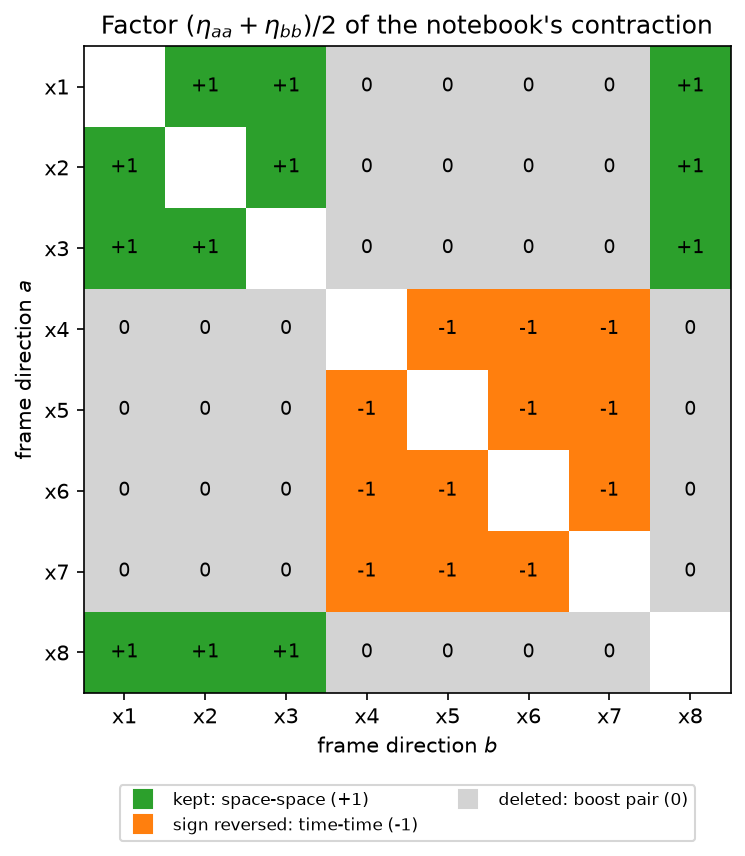

Figure 06c.1 saved as Revision/textbook/figures/06c_1_pair_kinds.png


In [5]:
from matplotlib.colors import ListedColormap  # a colour map with a few colours

grid = np.full((8, 8), 3)  # 3 = the diagonal (white)
for a in range(8):
    for b in range(8):
        if a != b:
            grid[a, b] = {1: 0, -1: 1, 0: 2}[int(factor[a][b])]  # colour number
colours = ListedColormap(["tab:green", "tab:orange", "lightgray", "white"])
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.imshow(grid, cmap=colours, vmin=-0.5, vmax=3.5)
for a in range(8):
    for b in range(8):
        if a != b:
            ax.text(b, a, f"{int(factor[a][b]):+d}" if factor[a][b] else "0",
                    ha="center", va="center", fontsize=9)
ax.set_xticks(range(8), NAMES)
ax.set_yticks(range(8), NAMES)
ax.set_xlabel("frame direction $b$")
ax.set_ylabel("frame direction $a$")
ax.set_title("Factor $(\\eta_{aa} + \\eta_{bb})/2$ of the notebook's contraction")
ax.grid(False)
for colour, label in (("tab:green", "kept: space-space (+1)"),
                      ("tab:orange", "sign reversed: time-time (-1)"),
                      ("lightgray", "deleted: boost pair (0)")):
    ax.plot([], [], "s", color=colour, markersize=9, label=label)  # legend only
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=2, fontsize=8)
save_figure(fig, "pair_kinds",
            "What the missing metric factor does to each pair of frame directions "
            "of the author's frame metric. Rows $a$ and columns $b$ are the frame "
            "directions $x1$ to $x8$; each square shows the factor $(\\eta_{aa} + "
            "\\eta_{bb})/2$ by which the notebook's contraction multiplies the part "
            "of the pair: green $+1$, kept (both space-like: $x1, x2, x3, x8$); "
            "orange $-1$, sign reversed (both time-like: $x4, x5, x6, x7$); gray "
            "$0$, deleted (one space-like and one time-like direction, a boost "
            "pair); white diagonal, no pair. Of the 28 pairs 6 are kept, 6 "
            "reversed and 16 deleted.")

## 7. Two flat planes: where the mistake is invisible, and where it is total

**The polar plane** ($ds^2 = dr^2 + r^2d\varphi^2$, $\eta = \mathrm{diag}(1, 1)$,
vielbein $\mathrm{diag}(1, r)$, gammas $\sigma_1, \sigma_2$). Both frame directions
are space-like, so lowering changes nothing and the two contractions must agree;
the cell checks that both give $\Omega_\varphi = -\frac i2\sigma_3$, the result of
Notebook 06a.

**The Milne wedge** ($ds^2 = -d\tau^2 + \tau^2d\theta^2$, $\eta =
\mathrm{diag}(-1, +1)$, vielbein $\mathrm{diag}(1, \tau)$). Two REAL 2 x 2 gammas
with $(\gamma^0)^2 = -1$, $(\gamma^1)^2 = +1$, $\gamma^0\gamma^1 +
\gamma^1\gamma^0 = 0$ are $\gamma^0 = \begin{pmatrix}0 & 1\\ -1 & 0\end{pmatrix}$
and $\gamma^1 = \begin{pmatrix}0 & 1\\ 1 & 0\end{pmatrix}$ (the cell checks the
three relations). The only Christoffel symbols are $\Gamma^\tau{}_{\theta\theta} =
\tau$ and $\Gamma^\theta{}_{\tau\theta} = 1/\tau$, and the formula gives the mixed
components $\omega_\theta{}^0{}_1 = \omega_\theta{}^1{}_0 = 1$: SYMMETRIC, as for
every boost pair. Lowered, $\omega_{\theta 01} = -1 = -\omega_{\theta 10}$. The
plane is flat, but the frame is BOOSTED by the rapidity $\theta$ as one moves
along $\theta$ (left picture of the next figure); the correct spinor connection
$\Omega_\theta = -\frac12\gamma^0\gamma^1$ records this, and equals
$-(\partial_\theta U)U^{-1}$ for the spinor boost $U(\theta) = \cosh\frac\theta2 +
\sinh\frac\theta2\,\gamma^0\gamma^1$. A change of frame by a spin transformation
$R(\theta)$ changes the spinor connection into $R\,\Omega_\theta R^{-1} -
(\partial_\theta R)R^{-1}$; with $R = U$ applied to the connection 0 of the
Cartesian frame $(t, y)$ this gives $\Omega_\theta$, so $U$ carries the Cartesian
frame into the Milne frame, and with $R = U^{-1}$ it gives $U^{-1}\Omega_\theta U -
(\partial_\theta U^{-1})U = 0$: the inverse boost $U^{-1}$ removes the connection
(the cell checks both). The notebook's contraction gives
$\Omega^{nb} = 0$: it deletes the whole connection. The cell also checks the
divergence form $\gamma^\mu\Omega_\mu = \frac{1}{2\sqrt{|g|}}\sum_\mu
\partial_\mu(\sqrt{|g|}\gamma^\mu) = \gamma^0/(2\tau)$ (here $\sqrt{|g|} = \tau$),
which the notebook's value $0$ violates.

In [6]:
r, phi = sp.symbols("r phi", positive=True)  # the polar plane
sigma1 = sp.Matrix([[0, 1], [1, 0]])
sigma2 = sp.Matrix([[0, -sp.I], [sp.I, 0]])
sigma3 = sp.Matrix([[1, 0], [0, -1]])
polar_S = generators([sigma1, sigma2])
polar_e = sp.diag(1, r)  # unit radial and unit angular direction
polar_mixed = mixed_spin_connection(polar_e, christoffel(sp.diag(1, r**2), [r, phi]),
                                    [r, phi])
polar_Omega = contract(lower_first_index(polar_mixed, [1, 1]), polar_S)
polar_Omega_nb = contract(polar_mixed, polar_S)
check(polar_Omega == polar_Omega_nb and polar_Omega[1] == -sp.I / 2 * sigma3,
      "polar plane (eta = +1, +1): both contractions give Omega_phi = -(i/2) sigma3")

tau = sp.Symbol("tau", positive=True)  # the Milne wedge: tau > 0
theta = sp.Symbol("theta", real=True)  # the rapidity coordinate
g0 = sp.Matrix([[0, 1], [-1, 0]])  # real, squares to -1 (the time direction)
g1 = sp.Matrix([[0, 1], [1, 0]])  # real, squares to +1 (the space direction)
I2, Z2 = sp.eye(2), sp.zeros(2, 2)
check(g0 * g0 == -I2 and g1 * g1 == I2 and g0 * g1 + g1 * g0 == Z2,
      "Milne: real gammas with (g0)^2 = -1, (g1)^2 = +1, g0 g1 + g1 g0 = 0")
milne_S = generators([g0, g1])
milne_e = sp.diag(1, tau)  # unit time direction and unit space direction
milne_Gam = christoffel(sp.diag(-1, tau**2), [tau, theta])
milne_mixed = mixed_spin_connection(milne_e, milne_Gam, [tau, theta])
milne_lowered = lower_first_index(milne_mixed, [-1, 1])
say(f"Gamma^tau_thetatheta = {milne_Gam[0][1][1]}, "
    f"Gamma^theta_tautheta = {milne_Gam[1][0][1]}")
say(f"mixed: omega_theta^0_1 = {milne_mixed[1][0][1]}, "
    f"omega_theta^1_0 = {milne_mixed[1][1][0]}")
say(f"lowered: omega_theta01 = {milne_lowered[1][0][1]}, "
    f"omega_theta10 = {milne_lowered[1][1][0]}")
check(milne_mixed[1][0][1] == 1 and milne_mixed[1][1][0] == 1
      and milne_lowered[1][0][1] == -1 and milne_lowered[1][1][0] == 1,
      "Milne: mixed components symmetric (1, 1), lowered antisymmetric (-1, +1)")
milne_Omega = contract(milne_lowered, milne_S)
milne_Omega_nb = contract(milne_mixed, milne_S)
X2 = g0 * g1  # gamma^0 gamma^1, the boost generator of the plane (X2^2 = 1)
check(milne_Omega[0] == Z2 and milne_Omega[1] == -X2 / 2
      and milne_Omega_nb == [Z2, Z2],
      "Milne: Omega_theta = -(1/2) g0 g1, but the notebook's contraction gives 0")
U = sp.cosh(theta / 2) * I2 + sp.sinh(theta / 2) * X2  # the spinor boost
removed = U.inv() * milne_Omega[1] * U - U.inv().diff(theta) * U  # frame change U^-1
check(matrix_is_zero(-U.diff(theta) * U.inv() - milne_Omega[1])
      and matrix_is_zero(removed),
      "Milne: Omega_theta = -(dU/dtheta) U^-1, U = cosh(theta/2) + sinh(theta/2) g0 g1; "
      "U^-1 removes it")
milne_gup = curved_gammas(milne_e, [g0, g1])  # gamma^tau = g0, gamma^theta = g1/tau
slash_milne = (milne_gup[0] * milne_Omega[0] + milne_gup[1] * milne_Omega[1])
divergence_milne = ((tau * milne_gup[0]).diff(tau)
                    + (tau * milne_gup[1]).diff(theta)) / (2 * tau)
check(matrix_is_zero(slash_milne - g0 / (2 * tau))
      and matrix_is_zero(divergence_milne - slash_milne),
      "Milne: gamma^mu Omega_mu = g0/(2 tau) = the divergence form (notebook: 0)")

PASS polar plane (eta = +1, +1): both contractions give Omega_phi = -(i/2) sigma3
PASS Milne: real gammas with (g0)^2 = -1, (g1)^2 = +1, g0 g1 + g1 g0 = 0
Gamma^tau_thetatheta = tau, Gamma^theta_tautheta = 1/tau
mixed: omega_theta^0_1 = 1, omega_theta^1_0 = 1
lowered: omega_theta01 = -1, omega_theta10 = 1
PASS Milne: mixed components symmetric (1, 1), lowered antisymmetric (-1, +1)
PASS Milne: Omega_theta = -(1/2) g0 g1, but the notebook's contraction gives 0
PASS Milne: Omega_theta = -(dU/dtheta) U^-1, U = cosh(theta/2) + sinh(theta/2) g0 g1;
    U^-1 removes it
PASS Milne: gamma^mu Omega_mu = g0/(2 tau) = the divergence form (notebook: 0)


The next cell draws the Milne wedge. On the left, in the flat plane with the space
coordinate $y$ horizontal and the time $t$ vertical, the two curves $\tau = 1$ and
$\tau = 2$ (hyperbolas $t^2 - y^2 = \tau^2$) and, at five values of $\theta$, the
frame: the unit time direction $e_{(0)} = (\sinh\theta, \cosh\theta)$ (blue) and
the unit space direction $e_{(1)} = (\cosh\theta, \sinh\theta)$ (orange), in
$(y, t)$ components. Moving along $\theta$ the frame is boosted: both arrows tilt
towards the light lines $t = \pm y$. On the right, the two diagonal entries of the
spinor boost $U(\theta)$; since $\gamma^0\gamma^1 = \mathrm{diag}(1, -1)$ they are
$e^{\theta/2}$ and $e^{-\theta/2}$, with $\cosh\frac\theta2$ and
$\sinh\frac\theta2$ for comparison. Unlike the spinor rotation of Notebook 06a they
are real and never come back: a boost has no full turn.

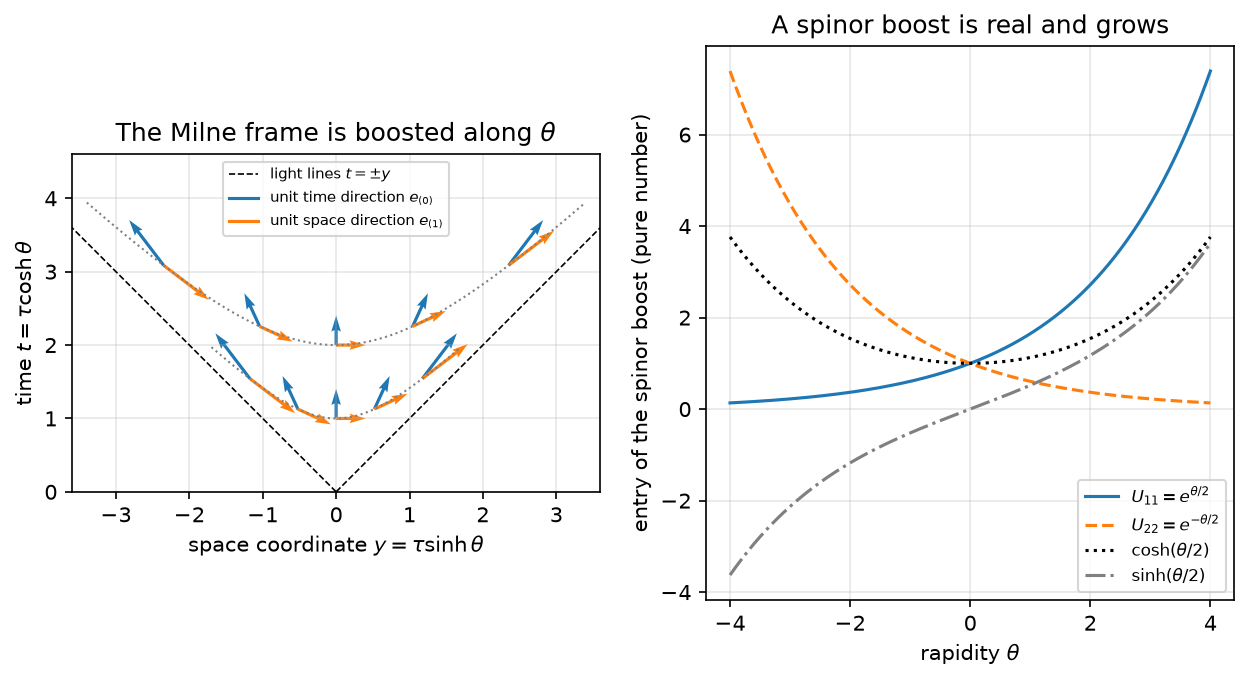

Figure 06c.2 saved as Revision/textbook/figures/06c_2_milne_frame_and_spin_boost.png


In [7]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.8))
curve = np.linspace(-1.3, 1.3, 200)  # values of theta for the hyperbolas
for radius in (1.0, 2.0):
    ax_left.plot(radius * np.sinh(curve), radius * np.cosh(curve), ":",
                 color="gray", linewidth=1.0)
    for rapidity in (-1.0, -0.5, 0.0, 0.5, 1.0):
        py, pt = radius * np.sinh(rapidity), radius * np.cosh(rapidity)  # the point
        ax_left.quiver(py, pt, np.sinh(rapidity), np.cosh(rapidity),
                       color="tab:blue", angles="xy", scale_units="xy", scale=2.5,
                       width=0.006)  # e_(0), the unit time direction
        ax_left.quiver(py, pt, np.cosh(rapidity), np.sinh(rapidity),
                       color="tab:orange", angles="xy", scale_units="xy",
                       scale=2.5, width=0.006)  # e_(1), the unit space direction
light = np.linspace(0.0, 3.6, 2)
ax_left.plot(light, light, "--", color="black", linewidth=0.8)  # t = y
ax_left.plot(-light, light, "--", color="black", linewidth=0.8,
             label="light lines $t = \\pm y$")  # t = -y
ax_left.plot([], [], color="tab:blue", label="unit time direction $e_{(0)}$")
ax_left.plot([], [], color="tab:orange", label="unit space direction $e_{(1)}$")
ax_left.set_xlim(-3.6, 3.6)
ax_left.set_ylim(0.0, 4.6)
ax_left.set_aspect("equal")
ax_left.set_xlabel("space coordinate $y = \\tau\\sinh\\theta$")
ax_left.set_ylabel("time $t = \\tau\\cosh\\theta$")
ax_left.set_title("The Milne frame is boosted along $\\theta$")
ax_left.legend(loc="upper center", fontsize=7)
rapidities = np.linspace(-4.0, 4.0, 401)
ax_right.plot(rapidities, np.exp(rapidities / 2),
              label="$U_{11} = e^{\\theta/2}$")
ax_right.plot(rapidities, np.exp(-rapidities / 2), "--",
              label="$U_{22} = e^{-\\theta/2}$")
ax_right.plot(rapidities, np.cosh(rapidities / 2), ":", color="black",
              label="$\\cosh(\\theta/2)$")
ax_right.plot(rapidities, np.sinh(rapidities / 2), "-.", color="gray",
              label="$\\sinh(\\theta/2)$")
ax_right.set_xlabel("rapidity $\\theta$")
ax_right.set_ylabel("entry of the spinor boost (pure number)")
ax_right.set_title("A spinor boost is real and grows")
ax_right.legend(fontsize=8)
save_figure(fig, "milne_frame_and_spin_boost",
            "The Milne wedge, a flat plane with one time in which the notebook's "
            "contraction deletes the whole spin connection. Left: the flat plane "
            "with the space coordinate $y$ horizontal and the time $t$ vertical "
            "(pure numbers); dotted, the curves $\\tau = 1$ and $\\tau = 2$; "
            "dashed, the light lines $t = \\pm y$; arrows, the frame at the "
            "rapidities $\\theta = -1, -0.5, 0, 0.5, 1$: unit time direction "
            "(blue) and unit space direction (orange). Along $\\theta$ the frame is "
            "boosted, and the correct spin connection $\\omega_{\\theta 01} = -1$ "
            "records this rate. Right: the diagonal entries $e^{\\theta/2}$ and "
            "$e^{-\\theta/2}$ of the spinor boost $U(\\theta)$ that carries the "
            "Cartesian frame into the Milne frame (its inverse $U^{-1}$ removes the "
            "connection), with $\\cosh(\\theta/2)$ and $\\sinh(\\theta/2)$, versus "
            "$\\theta$: real and unbounded, unlike a spinor rotation.")

## 8. The author's metric: the correct and the notebook's spinor connection

The next cell builds the author's metric with its diagonal vielbein $f =
(e^{a_4}s\ (\times 3),\ 1,\ e^{-a_4}s\ (\times 3),\ \cot z)$, $s = \sin^{1/6}z$,
for an arbitrary function $a_4(x_4)$, computes the Christoffel symbols, the MIXED
spin connection and its lowered form, and compares the 12 nonzero lowered
components with the record (`omega_nonzero`). Then it builds the correct
$\Omega_\mu$, the notebook's $\Omega^{nb}_\mu$ and the three parts
$\Omega^{ss}_\mu$, $\Omega^{tt}_\mu$, $\Omega^{st}_\mu$, and checks the identity
of Section 4, $\Omega^{nb}_\mu = \Omega^{ss}_\mu - \Omega^{tt}_\mu$, for all eight
$\mu$. It prints, for each of the 12 lowered components, the kind of its pair and
what the notebook's contraction does to it.

In [8]:
from sympy.parsing.mathematica import parse_mathematica  # reads Wolfram notation

x = sp.symbols("x1:9", real=True)  # x[0] = x1, ..., x[3] = x4, ..., x[7] = x8
x4, x8 = x[3], x[7]
H = sp.Symbol("H", positive=True)  # the author's constant H > 0
a4 = sp.Function("a4")(x4)  # any function of the time
a4p = sp.Derivative(a4, x4)  # a4'
z = 6 * H * x8  # the hidden angle
s = sp.sin(z) ** sp.Rational(1, 6)
f = [sp.exp(a4) * s] * 3 + [sp.Integer(1)] + [sp.exp(-a4) * s] * 3 + [sp.cot(z)]
g = sp.diag(*[ETA[a] * f[a] ** 2 for a in range(8)])  # the author's metric
e = sp.diag(*f)  # the diagonal vielbein
Gam = christoffel(g, x)
mixed = mixed_spin_connection(e, Gam, x)  # omega_mu^a_b
omega = lower_first_index(mixed, ETA)  # omega_mu ab
# The record lists {mu, a, b, value} with a < b, numbered 1..8, in Wolfram notation.
text = FORMULAS["omega_nonzero"].replace("Derivative[1][a4][x4]", "a4p")
text = text.replace("a4[x4]", "a4")
names = {sp.Symbol("H"): H, sp.Symbol("x8"): x8, sp.Symbol("a4"): a4,
         sp.Symbol("a4p"): a4p}
omega_record = {(int(m) - 1, int(a) - 1, int(b) - 1): v.subs(names, simultaneous=True)
                for m, a, b, v in parse_mathematica(text)}
nonzero = {(mu, a, b): omega[mu][a][b] for mu in range(8) for a, b in pairs
           if omega[mu][a][b] != 0}
check(set(nonzero) == set(omega_record)
      and all(is_zero(nonzero[k] - omega_record[k]) for k in nonzero),
      "the 12 nonzero lowered components omega_mu ab equal the record",
      record=f"{THEORY_FILE}, formula omega_nonzero")
ACTION = {1: "kept", -1: "sign reversed", 0: "deleted"}
for (mu, a, b) in sorted(nonzero):
    k = int(factor[a][b])
    say(f"omega_{NAMES[mu]},{NAMES[a]}{NAMES[b]}: {KIND[k]} pair, {ACTION[k]}")
Omega = contract(omega, S)  # the correct spinor connection
Omega_nb = contract(mixed, S)  # the notebook's contraction


def part(kind):
    """The part of Omega that comes from the pairs of one kind."""
    return contract([[[omega[mu][a][b] if factor[a][b] == kind else 0
                       for b in range(8)] for a in range(8)] for mu in range(8)], S)


Omega_ss, Omega_tt, Omega_st = part(1), part(-1), part(0)
check(all(matrix_is_zero(Omega[mu] - Omega_ss[mu] - Omega_tt[mu] - Omega_st[mu])
          and matrix_is_zero(Omega_nb[mu] - Omega_ss[mu] + Omega_tt[mu])
          for mu in range(8)),
      "Omega^nb_mu = Omega^ss_mu - Omega^tt_mu for all eight mu (boosts deleted)")

PASS the 12 nonzero lowered components omega_mu ab equal the record
     reproduces Revision/theory/field-theory.json, formula omega_nonzero
omega_x1,x1x4: boost pair, deleted
omega_x1,x1x8: space-space pair, kept
omega_x2,x2x4: boost pair, deleted
omega_x2,x2x8: space-space pair, kept
omega_x3,x3x4: boost pair, deleted
omega_x3,x3x8: space-space pair, kept
omega_x5,x4x5: time-time pair, sign reversed
omega_x5,x5x8: boost pair, deleted
omega_x6,x4x6: time-time pair, sign reversed
omega_x6,x6x8: boost pair, deleted
omega_x7,x4x7: time-time pair, sign reversed
omega_x7,x7x8: boost pair, deleted
PASS Omega^nb_mu = Omega^ss_mu - Omega^tt_mu for all eight mu (boosts deleted)


The previous cell showed that for $\mu = x1$ the boost part (the pair $x1, x4$, with
the rate $a_4'$) is deleted and the rotation part (the pair $x1, x8$, with $H$) is
kept, and that for $\mu = x5$ the boost part (the pair $x5, x8$, with $H$) is
deleted and the time-time part (the pair $x4, x5$, with $a_4'$) has its sign
reversed. The next cell checks the resulting closed forms

$$\Omega^{nb}_{x1} = e^{a_4}s\,H\,S^{x1\,x8}, \qquad
\Omega^{nb}_{x5} = +e^{-a_4}s\,a_4'\,S^{x4\,x5},$$

compared with the correct $\Omega_{x1} = e^{a_4}s\,(a_4'S^{x1\,x4} +
HS^{x1\,x8})$ and $\Omega_{x5} = -e^{-a_4}s\,(a_4'S^{x4\,x5} + HS^{x5\,x8})$
(Notebook 06a), and the same forms for $x2, x3$ and $x6, x7$.

In [9]:
closed_ok = True
for i in (0, 1, 2):  # the 3-space directions x1, x2, x3
    closed_ok = closed_ok and matrix_is_zero(
        Omega_nb[i] - sp.exp(a4) * s * H * S[i][7])  # pair (xi, x8) kept
    closed_ok = closed_ok and matrix_is_zero(
        Omega[i] - sp.exp(a4) * s * (a4p * S[i][3] + H * S[i][7]))
for t in (4, 5, 6):  # the extra times x5, x6, x7
    closed_ok = closed_ok and matrix_is_zero(
        Omega_nb[t] - sp.exp(-a4) * s * a4p * S[3][t])  # pair (x4, xt) reversed
    closed_ok = closed_ok and matrix_is_zero(
        Omega[t] + sp.exp(-a4) * s * (a4p * S[3][t] + H * S[t][7]))
check(closed_ok, "the closed forms of Omega_mu and Omega^nb_mu for x1 ... x3, "
      "x5 ... x7")

PASS the closed forms of Omega_mu and Omega^nb_mu for x1 ... x3, x5 ... x7


## 9. What the notebook's contraction would put into the field equation

The field equation contains the 16 x 16 matrix $\gamma^\mu\Omega_\mu$ (summed over
$\mu$). The next cell computes each term $\gamma^\mu\Omega_\mu$ (no sum) for both
contractions and writes it as $\alpha_\mu\gamma^{(x4)} + \beta_\mu\gamma^{(x8)}$
(the coefficients are found with traces, as in Notebook 06a:
$\alpha_\mu = -\mathrm{tr}(M\gamma^{(x4)})/16$ and $\beta_\mu =
\mathrm{tr}(M\gamma^{(x8)})/16$, and the cell checks that nothing else is left).
By hand: $\gamma^{x1}\Omega^{nb}_{x1} = \frac{1}{f_1}\gamma^{(x1)}\cdot f_1 H\cdot
\frac12\gamma^{(x1)}\gamma^{(x8)} = \frac H2\gamma^{(x8)}$ (because
$(\gamma^{(x1)})^2 = 1$), and $\gamma^{x5}\Omega^{nb}_{x5} =
\frac{1}{f_5}\gamma^{(x5)}\cdot f_5 a_4'\cdot\frac12\gamma^{(x4)}\gamma^{(x5)} =
-\frac{a_4'}{2}\gamma^{(x4)}(\gamma^{(x5)})^2 = \frac{a_4'}{2}\gamma^{(x4)}$
(because $\gamma^{(x5)}$ anticommutes with $\gamma^{(x4)}$ and
$(\gamma^{(x5)})^2 = -1$). Summed:

$$\gamma^\mu\Omega^{nb}_\mu = \tfrac{3H}{2}\gamma^{(x8)} + \tfrac{3a_4'}{2}
\gamma^{(x4)} \qquad\text{instead of}\qquad \gamma^\mu\Omega_\mu =
3H\gamma^{(x8)} .$$

Half of the hidden term is lost, and the time-direction terms no longer cancel:
with the wrong contraction the deflation would appear in this term. The cell
compares the correct total with the record (`gammaOmega_total`).

In [10]:
gup = curved_gammas(e, gamma)  # gamma^mu = gamma^a / f_a for mu = a


def split(M):
    """(alpha, beta, rest is zero) for M = alpha gamma^(x4) + beta gamma^(x8)."""
    alpha = sp.simplify(-(M * gamma[3]).trace() / 16)  # coefficient of gamma^(x4)
    beta = sp.simplify((M * gamma[7]).trace() / 16)  # coefficient of gamma^(x8)
    return alpha, beta, matrix_is_zero(M - alpha * gamma[3] - beta * gamma[7])


correct_terms = [split(gup[mu] * Omega[mu]) for mu in range(8)]
notebook_terms = [split(gup[mu] * Omega_nb[mu]) for mu in range(8)]
for mu in range(8):
    say(f"{NAMES[mu]}: correct ({correct_terms[mu][0]}, {correct_terms[mu][1]}), "
        f"notebook ({notebook_terms[mu][0]}, {notebook_terms[mu][1]})")
want_nb = [(0, H / 2)] * 3 + [(0, 0)] + [(a4p / 2, 0)] * 3 + [(0, 0)]
check(all(term[2] for term in correct_terms + notebook_terms)
      and all(is_zero(notebook_terms[mu][0] - want_nb[mu][0])
              and is_zero(notebook_terms[mu][1] - want_nb[mu][1]) for mu in range(8)),
      "notebook's terms: (H/2) gamma^(x8) for x1, x2, x3; (a4'/2) gamma^(x4) for "
      "x5, x6, x7")
slash = sum((gup[mu] * Omega[mu] for mu in range(8)), Z16)
slash_nb = sum((gup[mu] * Omega_nb[mu] for mu in range(8)), Z16)
total_text = FORMULAS["gammaOmega_total"].replace(chr(34), "")  # 3*H*gamma[x8]
total_record = parse_mathematica(total_text.replace("gamma[x8]", "G8")).subs(
    {sp.Symbol("H"): H, sp.Symbol("G8"): 1})
check(matrix_is_zero(slash - total_record * gamma[7])
      and record_passed(REPORT_PY, "gamma_mu_Omega_mu_equals_3H_gamma_x8"),
      "correct: gamma^mu Omega_mu = 3 H gamma^(x8)",
      record=f"{THEORY_FILE}, formula gammaOmega_total")
report("notebook: coefficient of gamma^(x8)", sum(t[1] for t in notebook_terms))
report("notebook: coefficient of gamma^(x4)", sum(t[0] for t in notebook_terms))
check(matrix_is_zero(slash_nb - 3 * H / 2 * gamma[7] - 3 * a4p / 2 * gamma[3]),
      "notebook: gamma^mu Omega^nb_mu = (3H/2) gamma^(x8) + (3 a4'/2) gamma^(x4)")

x1: correct (Derivative(a4(x4), x4)/2, H/2), notebook (0, H/2)
x2: correct (Derivative(a4(x4), x4)/2, H/2), notebook (0, H/2)
x3: correct (Derivative(a4(x4), x4)/2, H/2), notebook (0, H/2)
x4: correct (0, 0), notebook (0, 0)
x5: correct (-Derivative(a4(x4), x4)/2, H/2), notebook (Derivative(a4(x4), x4)/2, 0)
x6: correct (-Derivative(a4(x4), x4)/2, H/2), notebook (Derivative(a4(x4), x4)/2, 0)
x7: correct (-Derivative(a4(x4), x4)/2, H/2), notebook (Derivative(a4(x4), x4)/2, 0)
x8: correct (0, 0), notebook (0, 0)
PASS notebook's terms: (H/2) gamma^(x8) for x1, x2, x3; (a4'/2) gamma^(x4) for x5, x6, x7
PASS correct: gamma^mu Omega_mu = 3 H gamma^(x8)
     reproduces Revision/theory/field-theory.json, formula gammaOmega_total
RESULT notebook: coefficient of gamma^(x8) = 3*H/2
RESULT notebook: coefficient of gamma^(x4) = 3*Derivative(a4(x4), x4)/2
PASS notebook: gamma^mu Omega^nb_mu = (3H/2) gamma^(x8) + (3 a4'/2) gamma^(x4)


The next cell draws the per-direction table of the previous cell as bar charts:
for each direction $\mu$ the coefficient of $\gamma^{(x4)}$ in units of $a_4'$
(left) and of $\gamma^{(x8)}$ in units of $H$ (right), for the correct contraction
(dark bars) and the notebook's (light bars). On the left the correct bars cancel
in pairs ($+\frac12$ three times, $-\frac12$ three times), while the notebook's
three bars $+\frac12$ do not cancel; on the right the notebook keeps only the
three 3-space bars.

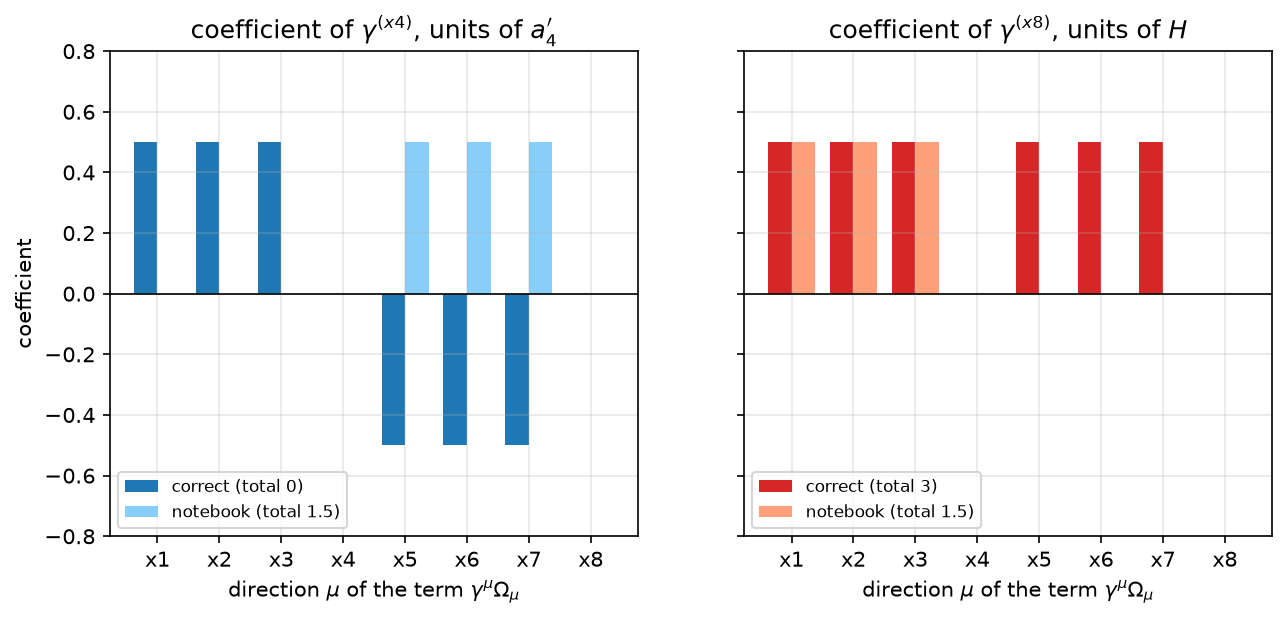

Figure 06c.3 saved as Revision/textbook/figures/06c_3_per_direction_comparison.png


In [11]:
positions = np.arange(8)
width = 0.38  # the width of one bar; two bars side by side per direction
alpha_c = [float(sp.simplify(t[0] / a4p)) for t in correct_terms]  # units of a4'
alpha_n = [float(sp.simplify(t[0] / a4p)) for t in notebook_terms]
beta_c = [float(sp.simplify(t[1] / H)) for t in correct_terms]  # units of H
beta_n = [float(sp.simplify(t[1] / H)) for t in notebook_terms]
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(10.0, 4.2), sharey=True)
ax_left.bar(positions - width / 2, alpha_c, width, color="tab:blue",
            label=f"correct (total {sum(alpha_c):g})")
ax_left.bar(positions + width / 2, alpha_n, width, color="lightskyblue",
            label=f"notebook (total {sum(alpha_n):g})")
ax_right.bar(positions - width / 2, beta_c, width, color="tab:red",
             label=f"correct (total {sum(beta_c):g})")
ax_right.bar(positions + width / 2, beta_n, width, color="lightsalmon",
             label=f"notebook (total {sum(beta_n):g})")
ax_left.set_title("coefficient of $\\gamma^{(x4)}$, units of $a_4'$")
ax_right.set_title("coefficient of $\\gamma^{(x8)}$, units of $H$")
for ax in (ax_left, ax_right):
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xticks(positions, NAMES)
    ax.set_xlabel("direction $\\mu$ of the term $\\gamma^\\mu\\Omega_\\mu$")
    ax.set_ylim(-0.8, 0.8)
    ax.legend(fontsize=8, loc="lower left")
ax_left.set_ylabel("coefficient")
save_figure(fig, "per_direction_comparison",
            "The eight terms $\\gamma^\\mu\\Omega_\\mu$ (no sum) of the author's "
            "metric, each of the form $\\alpha_\\mu\\gamma^{(x4)} + "
            "\\beta_\\mu\\gamma^{(x8)}$, for the correct contraction (dark bars) "
            "and for the notebook's contraction of the mixed components (light "
            "bars), versus the direction $\\mu$. Left: $\\alpha_\\mu$ in units of "
            "$a_4'$; the correct values $+1/2$ for $x1, x2, x3$ and $-1/2$ for $x5, "
            "x6, x7$ cancel, the notebook's $+1/2$ for $x5, x6, x7$ add to $3/2$. "
            "Right: $\\beta_\\mu$ in units of $H$; the correct six values $1/2$ add "
            "to $3$, the notebook keeps only three of them, total $3/2$.")

The next cell shows the two totals as pictures of 16 x 16 matrices at the sample
point $H = 1$, $z = \pi/4$, $a_4 = 1/2$, $a_4' = 1/2$ (red positive, blue
negative, white zero, one colour scale for both). Left: the correct
$\gamma^\mu\Omega_\mu = 3H\gamma^{(x8)}$, the value 3 on two diagonal lines (the
identity blocks of $\gamma^{(x8)}$). Right: the notebook's
$\frac{3H}{2}\gamma^{(x8)} + \frac{3a_4'}{2}\gamma^{(x4)}$: the same lines with the
value 1.5, plus the pattern of $\gamma^{(x4)}$ with entries $\pm0.75$.

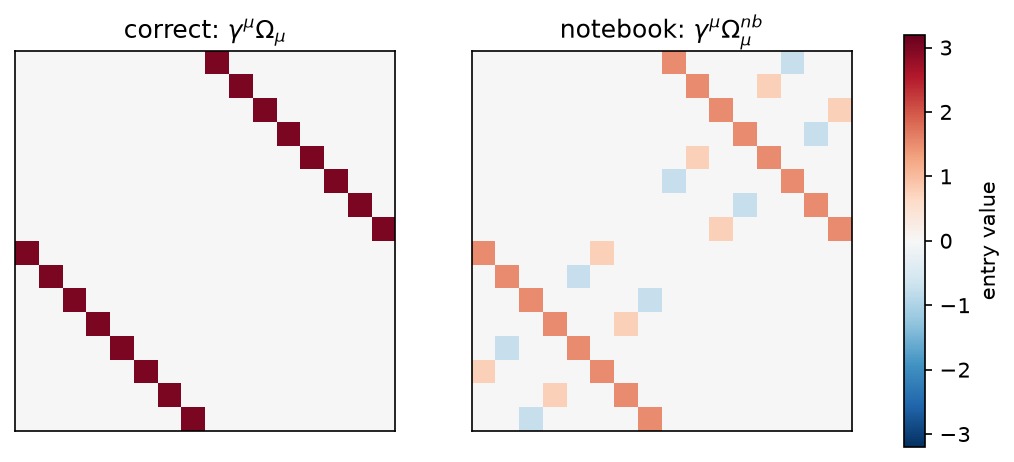

Figure 06c.4 saved as Revision/textbook/figures/06c_4_contraction_heat_maps.png


In [12]:
SAMPLE = {H: 1, x8: sp.pi / 24}  # H = 1 and z = 6 H x8 = pi/4


def at_sample(expr):
    """The decimal value of expr at H = 1, z = pi/4, a4 = 1/2, a4' = 1/2."""
    expr = sp.sympify(expr).subs(a4p, sp.Rational(1, 2))  # a4' first, then a4
    expr = expr.subs(a4, sp.Rational(1, 2))
    return float(sp.N(expr.subs(SAMPLE)))


def sample_table(matrix):
    """The matrix as an array of decimal numbers at the sample point."""
    return np.array([[at_sample(v) for v in row] for row in matrix.tolist()])


fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.2))
for ax, (title, matrix) in zip(axes, (
        ("correct: $\\gamma^\\mu\\Omega_\\mu$", slash),
        ("notebook: $\\gamma^\\mu\\Omega^{nb}_\\mu$", slash_nb))):
    image = ax.imshow(sample_table(matrix), cmap="RdBu_r", vmin=-3.2, vmax=3.2)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
fig.colorbar(image, ax=axes, shrink=0.85, label="entry value")
save_figure(fig, "contraction_heat_maps",
            "The total $\\gamma^\\mu\\Omega_\\mu$ as a 16 x 16 heat map at the sample "
            "point $H = 1$, $z = \\pi/4$, $a_4 = 1/2$, $a_4' = 1/2$ (rows and columns "
            "are the spinor components; red positive, blue negative, white zero; "
            "colour scale from $-3.2$ to $3.2$). Left: the correct value "
            "$3H\\gamma^{(x8)}$, the number 3 on two diagonal lines. Right: what the "
            "notebook's contraction of the mixed components would give, "
            "$\\frac{3H}{2}\\gamma^{(x8)} + \\frac{3a_4'}{2}\\gamma^{(x4)}$: the "
            "same lines with half the value, and the pattern of $\\gamma^{(x4)}$ "
            "with entries $\\pm 0.75$, which depends on the rate $a_4'$ of the "
            "deflation.")

## 10. The gammas are no longer covariantly constant

With the correct $\Omega_\mu$ the curved gammas are covariantly constant,
$D_\mu\gamma^\nu = 0$ for all 64 pairs $(\mu, \nu)$ (Notebook 06a; the Revision
record). Replace $\Omega_\mu$ by $\Omega^{nb}_\mu$:

$$D^{nb}_\mu\gamma^\nu = \partial_\mu\gamma^\nu +
\sum_\lambda\Gamma^\nu{}_{\mu\lambda}\gamma^\lambda + [\Omega^{nb}_\mu, \gamma^\nu]
= D_\mu\gamma^\nu + [\Omega^{nb}_\mu - \Omega_\mu, \gamma^\nu] =
[\Omega^{nb}_\mu - \Omega_\mu, \gamma^\nu] .$$

The first step adds and subtracts $[\Omega_\mu, \gamma^\nu]$; the second uses
$D_\mu\gamma^\nu = 0$. The next cell computes both versions for all 64 pairs,
checks the correct one against the record, checks this identity, counts the pairs
$(\mu, \nu)$ in which $D^{nb}_\mu\gamma^\nu$ is not zero and the number of its
nonzero entries (exact counts of this notebook), and checks that the defining
property $[\Omega_\mu, \gamma^a] = -\sum_b\omega_\mu{}^a{}_b\gamma^b$ fails for
$\Omega^{nb}$.

In [13]:
violation = {}  # (mu, nu) -> D^nb_mu gamma^nu, for the pairs where it is not zero
correct_ok, identity_ok, entries = True, True, 0
for mu in range(8):
    for nu in range(8):
        common = gup[nu].diff(x[mu]) + sum((Gam[nu][mu][lam] * gup[lam]
                                            for lam in range(8)), Z16)
        D_correct = common + Omega[mu] * gup[nu] - gup[nu] * Omega[mu]
        D_nb = common + Omega_nb[mu] * gup[nu] - gup[nu] * Omega_nb[mu]
        difference = Omega_nb[mu] - Omega[mu]
        correct_ok = correct_ok and matrix_is_zero(D_correct)
        identity_ok = identity_ok and matrix_is_zero(
            D_nb - (difference * gup[nu] - gup[nu] * difference))
        nonzero_entries = sum(1 for v in D_nb if not is_zero(v))
        if nonzero_entries:
            violation[(mu, nu)] = D_nb
            entries += nonzero_entries
check(correct_ok and record_passed(REPORT_PY, "covariant_constancy_D_mu_gamma_nu"),
      "correct: D_mu gamma^nu = 0 for all 64 pairs",
      record=f"{REPORT_PY}, check covariant_constancy_D_mu_gamma_nu")
check(identity_ok, "D^nb_mu gamma^nu = [Omega^nb_mu - Omega_mu, gamma^nu], all 64")
report("pairs (mu, nu) with D^nb_mu gamma^nu not zero", len(violation))
report("nonzero entries of these 16 x 16 matrices", entries)
say("violated pairs: " + ", ".join(f"({NAMES[m]},{NAMES[n]})"
                                   for m, n in sorted(violation)))
check(len(violation) == 15 and entries == 288,
      "notebook: D^nb_mu gamma^nu is not zero in 15 of 64 pairs (288 entries)")
failures = [(mu, a) for mu in range(8) for a in range(8) if not matrix_is_zero(
    Omega_nb[mu] * gamma[a] - gamma[a] * Omega_nb[mu]
    + sum((mixed[mu][a][b] * gamma[b] for b in range(8)), Z16))]
report("pairs (mu, a) where the defining property fails for Omega^nb", len(failures))
check(len(failures) > 0 and all(matrix_is_zero(
    Omega[mu] * gamma[a] - gamma[a] * Omega[mu]
    + sum((mixed[mu][a][b] * gamma[b] for b in range(8)), Z16))
    for mu in range(8) for a in range(8)),
      "the defining property holds for Omega and fails for Omega^nb",
      record=f"{REPORT_WL}, check S_rotates_gamma_with_omega")

PASS correct: D_mu gamma^nu = 0 for all 64 pairs
     reproduces Revision/theory/reports/python-field-theory.json, check
    covariant_constancy_D_mu_gamma_nu
PASS D^nb_mu gamma^nu = [Omega^nb_mu - Omega_mu, gamma^nu], all 64
RESULT pairs (mu, nu) with D^nb_mu gamma^nu not zero = 15
RESULT nonzero entries of these 16 x 16 matrices = 288
violated pairs: (x1,x1), (x1,x4), (x2,x2), (x2,x4), (x3,x3), (x3,x4), (x5,x4), (x5,x5),
    (x5,x8), (x6,x4), (x6,x6), (x6,x8), (x7,x4), (x7,x7), (x7,x8)
PASS notebook: D^nb_mu gamma^nu is not zero in 15 of 64 pairs (288 entries)
RESULT pairs (mu, a) where the defining property fails for Omega^nb = 15
PASS the defining property holds for Omega and fails for Omega^nb
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    S_rotates_gamma_with_omega


The next cell draws where the covariant constancy fails: an 8 x 8 grid with one
square for each pair $(\mu, \nu)$, coloured by the largest absolute value of the
256 entries of $D^{nb}_\mu\gamma^\nu$ at the sample point (white: zero). With the
correct connection every square would be white.

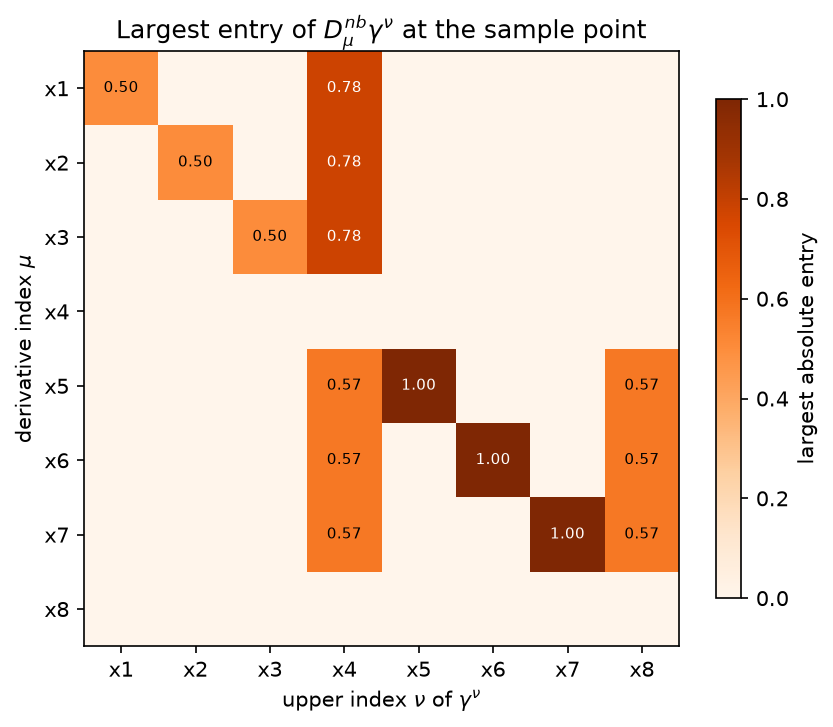

Figure 06c.5 saved as Revision/textbook/figures/06c_5_constancy_violation.png


In [14]:
size = np.zeros((8, 8))
for (mu, nu), matrix in violation.items():
    size[mu, nu] = np.abs(sample_table(matrix)).max()  # the largest entry
fig, ax = plt.subplots(figsize=(6.4, 5.4))
image = ax.imshow(size, cmap="Oranges", vmin=0.0)
for (mu, nu) in violation:
    dark = size[mu, nu] > 0.6 * size.max()  # white digits on dark squares
    ax.text(nu, mu, f"{size[mu, nu]:.2f}", ha="center", va="center", fontsize=7,
            color="white" if dark else "black")
ax.set_xticks(range(8), NAMES)
ax.set_yticks(range(8), NAMES)
ax.set_xlabel("upper index $\\nu$ of $\\gamma^\\nu$")
ax.set_ylabel("derivative index $\\mu$")
ax.set_title("Largest entry of $D^{nb}_\\mu\\gamma^\\nu$ at the sample point")
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.8, label="largest absolute entry")
save_figure(fig, "constancy_violation",
            "Where the notebook's contraction breaks the covariant constancy of the "
            "gammas: for each pair of coordinates, the derivative index $\\mu$ "
            "(rows) and the upper index $\\nu$ (columns), the largest absolute "
            "entry of the 16 x 16 matrix $D^{nb}_\\mu\\gamma^\\nu$ at the sample "
            "point $H = 1$, $z = \\pi/4$, $a_4 = 1/2$, $a_4' = 1/2$ (pure "
            "numbers; white is zero). Exactly 15 of the 64 pairs are nonzero, all "
            "in the rows of the six warped directions; with the correct spinor "
            "connection all 64 matrices vanish exactly.")

## 11. Why only the value $3H$ is right: the half-density term

Two facts of the Revision record single out the correct value.

**The divergence form.** Because $\{\gamma^\mu, \Omega_\mu\} = 0$ for each $\mu$
and $D_\mu\gamma^\nu = 0$, the correct contraction equals
$\frac{1}{2\sqrt{|g|}}\sum_\mu\partial_\mu(\sqrt{|g|}\,\gamma^\mu)$ (Notebook 06a),
a quantity built from the metric and the vielbein alone. The cell checks that it
equals the correct value and not the notebook's.

**The hidden-direction operator.** For fields that depend on $x_8$ only, the
derivative part of the field equation along $x8$ is the operator $A_c q =
\tan z\,\partial_{x8}q + c\,q$, where $c$ is the coefficient of $\gamma^{(x8)}$ in
$\gamma^\mu\Omega_\mu$. The volume weight of the hidden direction is $\sqrt{|g|} =
\cos z$. Compute, with the product rule and $\partial_{x8}\sin z = 6H\cos z$:

$$\partial_{x8}(\sin z\,p\,q) = 6H\cos z\,p\,q + \sin z\,(p'q + p\,q') ,$$

$$\cos z\,\big(p\,A_cq + (A_cp)\,q\big) = \sin z\,(p\,q' + p'q) + 2c\cos z\,p\,q$$

(using $\cos z\tan z = \sin z$). Subtracting,

$$\cos z\,\big(p\,A_cq + (A_cp)\,q\big) - \partial_{x8}(\sin z\,p\,q) =
(2c - 6H)\cos z\,p\,q .$$

For $c = 3H$ the right side vanishes: integrated over $x_8$, $\int\cos z\,p\,A_cq
= -\int\cos z\,(A_cp)\,q$ plus a boundary term, so $A_{3H}$ is antisymmetric for
the weight $\cos z$; this is the record's formula `hidden_direction_hermiticity`,
and it is what makes the operator of the quantum theory Hermitian (up to boundary
conditions). For the notebook's $c = \frac{3H}{2}$ the term $-3H\cos z\,p\,q$
remains: no boundary term can absorb it. The next cell checks all of this exactly
for two arbitrary functions $p(x_8)$, $q(x_8)$.

In [15]:
sqrt_g = sp.cos(z)  # sqrt|det g| of the author's metric
divergence = sum(((sqrt_g * gup[mu]).diff(x[mu]) for mu in range(8)), Z16) / (2 * sqrt_g)
check(matrix_is_zero(divergence - slash) and not matrix_is_zero(divergence - slash_nb),
      "the divergence form equals the correct contraction, not the notebook's",
      record=f"{REPORT_WL}, check gammaOmega_divergence_form")
p = sp.Function("p")(x8)  # two arbitrary functions of x8
q = sp.Function("q")(x8)
c = sp.Symbol("c", real=True)  # the coefficient of gamma^(x8)


def A(u):
    """The hidden-direction operator A_c u = tan z du/dx8 + c u."""
    return sp.tan(z) * u.diff(x8) + c * u


leftover = sp.cos(z) * (p * A(q) + A(p) * q) - sp.diff(sp.sin(z) * p * q, x8)
check(is_zero(leftover - (2 * c - 6 * H) * sp.cos(z) * p * q),
      "cos z (p A_c q + (A_c p) q) - d8(sin z p q) = (2c - 6H) cos z p q")
record_text = FORMULAS["hidden_direction_hermiticity"]
check(is_zero(leftover.subs(c, 3 * H)) and "Tan[z] d8 + 3 H" in record_text
      and "= d8 (Sin[z] p q)" in record_text,
      "c = 3H: A_c is antisymmetric for the weight cos z up to d8(sin z p q)",
      record=f"{THEORY_FILE}, formula hidden_direction_hermiticity")
check(is_zero(leftover.subs(c, 3 * H / 2) + 3 * H * sp.cos(z) * p * q),
      "c = 3H/2 (notebook): the leftover -3 H cos z p q remains")

PASS the divergence form equals the correct contraction, not the notebook's
     reproduces Revision/theory/reports/wolfram-field-theory.json, check
    gammaOmega_divergence_form
PASS cos z (p A_c q + (A_c p) q) - d8(sin z p q) = (2c - 6H) cos z p q
PASS c = 3H: A_c is antisymmetric for the weight cos z up to d8(sin z p q)
     reproduces Revision/theory/field-theory.json, formula hidden_direction_hermiticity
PASS c = 3H/2 (notebook): the leftover -3 H cos z p q remains


The next cell draws the leftover coefficient $(2c/H - 6)\cos z$ (the factor in
front of $H\,p\,q$) versus the hidden angle $z$ for three values of $c$: the
correct $c = 3H$ (zero for every $z$), the notebook's $c = \frac32 H$, and $c = 0$
(no spin-connection term at all).

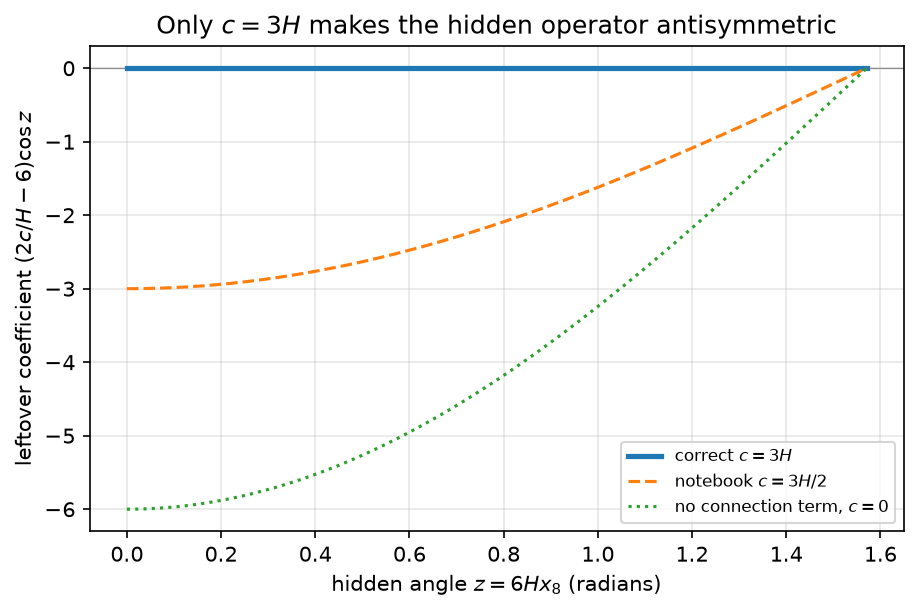

Figure 06c.6 saved as Revision/textbook/figures/06c_6_hermiticity_defect.png


In [16]:
zz = np.linspace(0.0, np.pi / 2, 300)  # the hidden angle z from 0 to pi/2
fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.axhline(0.0, color="gray", linewidth=0.6, zorder=1)  # the zero line, underneath
for value, style, width, label in ((3.0, "-", 2.5, "correct $c = 3H$"),
                                   (1.5, "--", 1.5, "notebook $c = 3H/2$"),
                                   (0.0, ":", 1.5, "no connection term, $c = 0$")):
    ax.plot(zz, (2 * value - 6) * np.cos(zz), style, linewidth=width, label=label,
            zorder=3)  # drawn above the zero line
ax.set_xlabel("hidden angle $z = 6Hx_8$ (radians)")
ax.set_ylabel("leftover coefficient $(2c/H - 6)\\cos z$")
ax.set_title("Only $c = 3H$ makes the hidden operator antisymmetric")
ax.legend(fontsize=8)
save_figure(fig, "hermiticity_defect",
            "The term that spoils the antisymmetry of the hidden-direction operator "
            "$A_c = \\tan z\\,\\partial_{x8} + c$ for the volume weight $\\cos z$: "
            "the coefficient $(2c/H - 6)\\cos z$ of $H\\,p\\,q$ in $\\cos "
            "z\\,(p\\,A_c q + (A_c p)\\,q) - \\partial_{x8}(\\sin z\\,p\\,q)$, a pure "
            "number, versus the hidden angle $z$ in radians, for the correct value "
            "$c = 3H$ of the spin-connection term (solid, zero everywhere), for the "
            "notebook's value $c = 3H/2$ (dashed) and for no spin-connection term, "
            "$c = 0$ (dotted). Only the correct value leaves nothing but a boundary "
            "term; the solid line lies on the zero line.")

## 12. The last checks

The last cell checks that every check of the Revision reports that states a
correct result reproduced here is recorded there as passed, that all six figure
files exist in the folder Revision/textbook/figures, and prints the number of
checks that passed.

In [17]:
cited = {
    REPORT_PY: ["clifford_relations", "gammas_real", "vielbein_postulate",
                "spin_connection_antisymmetric", "covariant_constancy_D_mu_gamma_nu",
                "gamma_mu_Omega_mu_equals_3H_gamma_x8", "divergence_of_sqrtg_gamma"],
    REPORT_WL: ["omega_components", "S_rotates_gamma_with_omega",
                "gamma_covariantly_constant", "gammaOmega_equals_3H_gamma_x8",
                "gammaOmega_divergence_form", "good_sector_hermiticity_curved"],
}
count = sum(len(names) for names in cited.values())
check(all(record_passed(path, name) for path, names in cited.items()
          for name in names),
      f"the {count} cited record checks are recorded as passed")
expected = [f"06c_{k}_{name}.png" for k, name in enumerate([
    "pair_kinds", "milne_frame_and_spin_boost", "per_direction_comparison",
    "contraction_heat_maps", "constancy_violation", "hermiticity_defect"], 1)]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in expected),
      "all six figure files exist")
all_checks_passed()

PASS the 13 cited record checks are recorded as passed
PASS all six figure files exist
ALL 27 CHECKS PASSED (notebook 06c)


## 13. What this notebook showed

- The notebook's contraction $\Omega^{nb}_\mu = \frac12\sum_{a,b}
  \omega_\mu{}^a{}_b S^{ab}$ of the MIXED components equals $\sum_{a<b}
  \frac12(\eta_{aa} + \eta_{bb})\,\omega_{\mu ab}S^{ab}$: it keeps the 6
  space-space parts, reverses the sign of the 6 time-time parts and deletes the 16
  boost parts of every spin connection (PROVED, exact).
- With a positive metric (the polar plane) the two contractions agree, so the
  mistake cannot show up there; in the Milne wedge, a flat plane with one time, the
  frame is boosted along $\theta$ and the notebook's contraction deletes the whole
  connection $\Omega_\theta = -\frac12\gamma^0\gamma^1$ (PROVED).
- For the author's metric the correct spin connection reproduces the record
  (`omega_nonzero`, $\gamma^\mu\Omega_\mu = 3H\gamma^{(x8)}$, $D_\mu\gamma^\nu = 0$),
  while the notebook's contraction would give $\gamma^\mu\Omega^{nb}_\mu =
  \frac{3H}{2}\gamma^{(x8)} + \frac{3a_4'}{2}\gamma^{(x4)}$ and would break the
  covariant constancy of the gammas in 15 of the 64 pairs $(\mu, \nu)$, with 288
  nonzero entries (COMPUTED exactly here; not a Revision result).
- Only the correct value $3H$ equals the divergence form
  $\frac{1}{2\sqrt{|g|}}\partial_\mu(\sqrt{|g|}\gamma^\mu)$ and makes the
  hidden-direction operator $\tan z\,\partial_{x8} + 3H$ antisymmetric for the
  volume weight $\cos z$ up to the boundary term $\partial_{x8}(\sin z\,p\,q)$
  (reproduces the record's formula `hidden_direction_hermiticity`); the
  notebook's value leaves the term $-3H\cos z\,p\,q$.
- This is why the Revision record, and this book, use the lowered components
  $\omega_{\mu ab} = \eta_{aa}\,\omega_\mu{}^a{}_b$ in the spinor connection.